### qwen-0.6b离线大模型

使用[qwen-0.6b](https://huggingface.co/Qwen/Qwen3-0.6B)大模型写诗

In [1]:
import os
import re
import json
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from openai import OpenAI
from functools import partial
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model,PeftModel
from utils import *


FOLDER_PATH = os.getenv('LLM_GIT_PROJECT_LOCAL_PATH')

In [2]:
model_name = "model/qwen3-0.6b"

# load the tokenizer and the model
base_tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype="auto",
    device_map="auto"
)


D:\big_data\miniconda3\Lib\site-packages\torch\cuda\__init__.py:1036: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 10020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10\cuda\CUDAFunctions.cpp:109.)
  r = torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


In [3]:
generate_tang_poem(model,base_tokenizer,'秦川雄帝宅，函谷壮皇居。')

'山河入云深，江海涌波虚。白日随云去，寒霜照月迟。君不见星河远，风月共长时。'

实际上,让qwen3预训练模型写诗也能写得有模有模有样了，最终让大模型评分，发现和原句相差还是很大的。现在重新对qwen3-0.6b大模型进行微调，看一下是否能够改善评分。

### 模型微调

为了提升qwen-0.6模型写诗能力，利用`Tang_training_data.json`数据集里面的数据完成大模型的微调。模型微调过程在kaggle平台利用T4实现加速，具体实现过程如下：
- **模型加载与LoRA配置**
- **数据加载与分词**
- **模型微调训练(SFT)**
- **LoRA权重保存并加载**

#### **模型加载与LoRA配置**

模型加载：复用原生pad_token,简化pad_token逻辑

In [4]:
model_name = "model/qwen3-0.6b"

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.get_vocab().get("<|pad|>", tokenizer.eos_token)
tokenizer.padding_side = "right"

In [5]:
tokenizer.pad_token

'<|endoftext|>'

用`BitsAndBytesConfig`类实现模型的 4-bit 量化设置:大幅降低模型的 GPU 显存占用，让大模型能在显存较小的 GPU 上运行，同时尽量保留精度。
- `load_in_4bit=True`：启用 4-bit 量化加载模型，将模型权重压缩为 4 位存储；
- `bnb_4bit_use_double_quant`：开启 “双量化”（对量化后的权重再做一次量化），进一步压缩且减少精度损失；
- `bnb_4bit_quant_type="nf4"`：采用 “NormalFloat4” 量化类型（针对神经网络权重分布优化，比普通 4bit 精度更好）；
- `bnb_4bit_compute_dtype`：指定模型计算时的精度（根据 GPU 算力选bfloat16/float16，保证计算性能）。

In [6]:
def get_quant_config():
    if not torch.cuda.is_available():
        return None
    compute_dtype = torch.bfloat16 if torch.cuda.get_device_capability()[0] >=8.0 else torch.float16
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype
    )

bnb_config = get_quant_config()

设置模型参数及加载模型

In [7]:
model_kwargs = {
    # "trust_remote_code": True,
    'local_files_only': True,
    'device_map': 'auto' if torch.cuda.is_available() else 'cpu',
    'use_cache': False, 
}
# if bnb_config:
#     model_kwargs["quantization_config"] = bnb_config
    
model_name = 'model/qwen3-0.6b'
model = AutoModelForCausalLM.from_pretrained(model_name,** model_kwargs)

model.config.gradient_checkpointing = True
model.gradient_checkpointing_enable() 

[LoRA配置](https://huggingface.co/docs/peft/main/en/package_reference/lora)

论文：[LORA: LOW-RANK ADAPTATION OF LARGE LANGUAGE MODELS](https://arxiv.org/pdf/2106.09685)

核心配置参数（必选参数）：

- `r(秩/Rank)`：
    - 类型int,默认值:8；
    - LoRA 通过将高维权重更新分解为两个低秩矩阵$（A∈ℝ^(d×r)、B∈ℝ^(r×d)）$的乘积实现参数压缩，$r$ 远小于原模型隐藏层维度 $d$，因此 $r$ 越小，参数量越少、训练成本越低；
    - 小模型（<1B 参数）推荐 4-16；中等模型（1B-10B 参数）推荐 8-32；大模型（>10B 参数）推荐 16-64。
-  `lora_alpha（缩放因子）`:
    - 类型：int,默认值：16;
    - 与 r 配合使用的学习率缩放因子，核心公式为$ \Delta W = (lora\_alpha /r) × A × B$。其作用是平衡低秩矩阵更新的幅度，避免因 r 过小导致更新幅度过弱，或 r 过大导致更新不稳定；
    - 通常设为 $2×r$（如 r=16 时 lora_alpha=32），也可与 r 取值相等，确保梯度更新的稳定性和有效性。
-  `target_modules（目标模块）`：
    -  类型：List[str]（字符串列表），默认值：None（必须手动指定，否则报错）；
    -  指定需要插入 LoRA 低秩矩阵的模型层名称，仅对这些层进行参数微调，直接影响微调效果和显存占用。不同模型的层命名差异较大，需严格匹配模型架构的层名称。
    -  LLaMA/LLaMA 2/Qwen 等生成式模型：推荐 ["q_proj", "v_proj"]（注意力层的查询投影、值投影层，核心影响模型的语义捕捉能力），复杂场景可追加 ["k_proj", "o_proj"]；
    -  GPT-2/GPT-Neo 模型：["c_attn"]（注意力投影层，包含 Q、K、V 合并投影）
    -  ERT/RoBERTa 等编码器模型：["query", "value"]（bert 架构注意力层的查询、值投影）；
    -  T5/BART 等 seq2seq 模型：["q", "v"]（编码器和解码器的注意力层投影）。
-  `task_type（任务类型）`:
    -  类型：str（字符串）,默认值：None（必须手动指定）;
    -  指定 LoRA 适配的下游任务类型，PEFT 框架会根据任务类型自动调整模型输出层的处理逻辑（如损失函数选择、输出格式适配等）。
    -  官方支持的取值：
        -  "CAUSAL_LM"：因果语言模型（适用于文本生成任务，如 Qwen、GPT 系列模型）；
        -  "SEQ_CLS"：序列分类任务（如情感分析、文本分类）；
        -  "SEQ2SEQ_LM"：序列到序列生成任务（如机器翻译、文本摘要）；
        -  "TOKEN_CLS"：Token 级分类任务（如命名实体识别、词性标注）；
        -  "QUESTION_ANSWERING"：问答任务（如抽取式问答）。

其他配置参数（可选参数）

- `lora_dropout（LoRA dropout）`:
    - 类型：float（浮点数）,默认值：0.1;
    - 为LoRA 低秩矩阵的输入特征施加 Dropout 正则化，随机丢弃部分特征，防止模型在小数据集上过拟合;
    -  训练数据量较小时（如 <1 万条），推荐 0.05-0.1；数据量充足时（如>10 万条），可设为 0（禁用 Dropout），避免丢失有效特征。
- `bias（偏置训练策略）`:
    - 类型：str（字符串）,默认值："none";
    - 控制是否训练原模型的偏置参数（bias），偏置参数数量较少，但可能影响模型的拟合精度。
    - 官方支持的取值：
        - "none"：不训练任何偏置参数（默认推荐，节省显存和计算资源，多数场景足够）；
        - "all"：训练原模型所有层的偏置参数（拟合能力更强，但参数量增加，易过拟合）；
        - "lora_only"：仅训练与 LoRA 模块相关的偏置参数（平衡拟合能力和参数量，适用于中等数据集）。
- `modules_to_save（需完整训练的模块）`:
    - 类型：List[str]（字符串列表）,默认值：None;
    - 指定需要 “完整训练”（而非 LoRA 微调）的模型层，这些层会保留全部参数并参与梯度更新，其余层仅通过 LoRA 微调。
    - 下游任务需调整模型输出层时（如分类任务的分类头、问答任务的输出投影层），例如分类任务可指定 ["classifier"]，文本生成任务通常无需设置（默认使用原模型生成头）。
- `inference_mode（推理模式开关）`:
    - 类型：bool（布尔值）, 默认值：True;
    - 推理时是否禁用 LoRA 模块的梯度计算，避免冗余的梯度存储和计算，节省内存。
    - 推理阶段保持默认 True；若需在推理时继续微调（如在线学习），设为 False。
- `merge_weights（权重合并开关）`:
    - 类型：bool（布尔值）,默认值：False;
    - 推理时是否将 LoRA 低秩矩阵权重与原模型权重合并为单一权重矩阵。合并后模型可脱离 PEFT 库独立运行，且推理速度提升（减少矩阵乘法次数）。
    - 训练阶段设为 False（便于单独保存 LoRA 适配器）；推理部署阶段设为 True（提升速度、降低部署依赖）。
- `fan_in_fan_out（权重布局适配）`
    - 类型：bool（布尔值），默认值：False；
    - 是否适配特定模型的权重矩阵布局（如 GPT-2 的 Conv1D 层权重为 (fan_out, fan_in) 格式，而非默认的 (fan_in, fan_out)）。
    - 仅当模型权重布局特殊（如 GPT-2、GPT-Neo）且出现维度不匹配报错时，设为 True；其他模型（如 LLaMA、Qwen、BERT）保持 False。
- `init_lora_weights（初始化方式）`:
    -  类型：bool 或 str,默认值：True;
    -  指定 LoRA 低秩矩阵的初始化方式，影响模型收敛速度和微调效果;
    -  官方支持的取值：
        -  True 或 "gaussian"：使用高斯分布初始化矩阵 A，矩阵 B 初始化为全零（默认方式，兼容性好）；
        -  "pissa"：使用 PiSSA 初始化方法（基于模型预训练权重的低秩分解，收敛更快、效果更稳定，适用于大模型微调）；
        -  False：不自动初始化（不推荐，可能导致训练不稳定）。
- `use_rslora`:
    - 类型：bool（布尔值）,默认值：False;
    - 是否启用秩稳定化 LoRA（Rank-Stabilized LoRA），核心是将缩放因子改为 lora_alpha / sqrt(r)，避免因 r 变化导致更新幅度波动过大。
    - 当 r 取值较大（如 >32）或不同层使用不同 r 时，设为 True；普通场景保持 False 即可。

In [8]:
lora_config = LoraConfig(
    r=5,
    lora_alpha=5,
    target_modules=['q_proj','v_proj'],   #["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]  # 覆盖Attention+MLP层
    task_type='CAUSAL_LM',
    lora_dropout=0.1,
    inference_mode = False,
    init_lora_weights = 'pissa',
    
)

In [9]:
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 716,800 || all params: 596,766,720 || trainable%: 0.1201


#### **数据加载与分词**

In [10]:
dataset_path = os.path.join(FOLDER_PATH,os.path.join('dataset','poem'))
training_data = load_data(os.path.join(dataset_path,'Tang_training_data.json'))
testing_data = load_data(os.path.join(dataset_path,'Tang_testing_data.json'))

In [11]:
training_data[0]

{'instruction': '以下是一首唐詩的第一句話，請用你的知識判斷並完成整首詩。',
 'input': '秦川雄帝宅，函谷壯皇居。',
 'output': '綺殿千尋起，離宮百雉餘。連甍遙接漢，飛觀迥凌虛。雲日隱層闕，風煙出綺疎。'}

In [12]:
testing_data[0]

{'instruction': '以下是一首唐詩的第一句話，請用你的知識判斷並完成整首詩。', 'input': '雪霽銀妝素，桔高映瓊枝。'}

可以看到训练集包含提示词、输入和输出。测试集包含提示词和输入。这里发现用原先的提示词，输出的结果千奇百怪的，需要修改。

In [13]:
for data in training_data:
    data['instruction'] = '请输出这首唐诗后续的续写部分。'
for data in testing_data:
    data['instruction'] = '请输出这首唐诗后续的续写部分。'
data

{'instruction': '请输出这首唐诗后续的续写部分。', 'input': '瑤池阿母綺窗開，黃竹歌聲動地哀。'}

格式化数据格式

In [14]:
# #@save qwen3 prompt,适用于小批量单样本数据处理
def format_prompt(data_point):
    """极简ChatML格式（保留bos_token位置）"""
    instruction = data_point["instruction"].strip()
    input_text = data_point["input"].strip()
    output_text = data_point["output"].strip()
    
    if input_text:
        prompt = (
            f"<|im_start|>user\n{instruction}\n{input_text}<|im_end|>\n"
            f"<|im_start|>assistant\n{output_text}<|im_end|>"
        )
    else:
        prompt = (
            f"<|im_start|>user\n{instruction}<|im_end|>\n"
            f"<|im_start|>assistant\n{output_text}<|im_end|>"
        )
    return {"text": prompt}

#适用于批量化数据处理
def batch_format_prompt(batch_data):
    """适配batched=True的批量处理逻辑"""
    instructions = batch_data["instruction"]
    inputs = batch_data["input"]
    outputs = batch_data["output"]
    # formatted_texts = []
    res = {'inputs':[],'outputs':[]}
    
    for instr, inp, outp in zip(instructions, inputs, outputs):
        # 单个样本的格式化逻辑
        instr = instr.strip()
        inp = inp.strip()
        outp = outp.strip()
        res['inputs'].append(f"<|im_start|>user\n{instr}\n{inp}<|im_end|>\n")
        res['outputs'].append(f"<|im_start|>assistant\n{outp}<|im_end|>")
    return res

In [15]:
MAX_LEN = 128
#@save 删除token过长的数据，限制token长度
def filter_by_length(examples,tokenizer, max_len):
    '''
    包含bos_token的真实长度计算;
    这里如果使用多线程处理数据，必须添加tokenizer, max_length参数，避免无法读取主线程定义的对象；
    当批量化处理时候，返回应该是{"keep": lengths}，如果单样本处理时候返回值可以直接是lengths
    '''
    lengths = []
    for inp,oup in zip(examples['inputs'],examples['outputs']):
        # 模拟实际tokenize（含bos_token）
        prompt = inp + oup
        tokens = tokenizer.encode(prompt, add_special_tokens=True)
        lengths.append(len(tokens) <= max_len)
    return lengths

filtered_func = partial(filter_by_length, tokenizer=tokenizer, max_len=MAX_LEN)

将Json数据加载成Dataset对象，并且通过map方法，调用format_map和fileter_by_lenght批量化处理数据。

In [16]:
'''
Dataset对象
- 可以通过调用to_pandas()方法转换成DataFrame对象查看；
- 通过索引或者切片的形式进行查看；
- 通过take()方法采样。
'''
train_dataset = Dataset.from_list(training_data)
train_dataset = train_dataset.map(batch_format_prompt,batched=True,num_proc=4,remove_columns=["instruction", "input", "output"])
train_dataset = train_dataset.filter(filtered_func, batched=True, num_proc=4)
dataset_split = train_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = dataset_split["train"]
eval_dataset = dataset_split["test"]

Map (num_proc=4):   0%|          | 0/5001 [00:00<?, ? examples/s]

Filter (num_proc=4):   0%|          | 0/5001 [00:00<?, ? examples/s]

In [17]:
train_dataset.to_pandas().head()

,inputs,outputs
0,<|im_start|>user\n请输出这首唐诗后续的续写部分。\n聞有南河信，傳聞殺畫師...,<|im_start|>assistant\n始知君惠重，更遣畫蛾眉。<|im_end|>
1,<|im_start|>user\n请输出这首唐诗后续的续写部分。\n郊扉俗遠長幽寂，野水春...,<|im_start|>assistant\n錦席淹留還出浦，葛巾欹側未迴船。尊當霞綺輕初散...
2,<|im_start|>user\n请输出这首唐诗后续的续写部分。\n南渡登州即水仙，西垣有...,<|im_start|>assistant\n因君相問爲官意，不賣毗陵負郭田。<|im_end|>
3,<|im_start|>user\n请输出这首唐诗后续的续写部分。\n曾聞宋玉宅，每欲到荆州...,<|im_start|>assistant\n此地生涯晚，遙悲水國秋。孤城一柱觀，落日九江流...
4,<|im_start|>user\n请输出这首唐诗后续的续写部分。\n流年一日復一日，世事何...,<|im_start|>assistant\n試向東林問禪伯，遣將心地學琉璃。<|im_end|>


分词

In [18]:
def tokenize(examples,tokenizer,max_len):
    tokenizers = []
    res = {'attention_mask':[],'input_ids':[],'labels':[]}
    # res = {'input_ids':[]}
    for inp,oup in zip(examples['inputs'],examples['outputs']):
        # prompt = inp+oup
        inp_token = tokenizer(inp,truncation=True,max_length=max_len,
                                  add_special_tokens=True)['input_ids']
        n_inp = len(inp_token)
        oup_token = tokenizer(oup,truncation=True,max_length=max_len,
                                  add_special_tokens=True)['input_ids']
        n_oup = len(oup_token)
        token_len = n_inp + n_oup
        res['input_ids'].append(inp_token+oup_token + (max_len-token_len)*[tokenizer.pad_token_id])
        res['labels'].append([-100]*n_inp+oup_token + (max_len-token_len)*[tokenizer.pad_token_id])
        res['attention_mask'].append([1]*token_len+[0]*(max_len-token_len))
    return res
                    
tokenize_func = partial(tokenize,tokenizer=tokenizer,max_len=MAX_LEN)

In [19]:
tokenized_train = train_dataset.map(tokenize_func, batched=True, num_proc=4)
tokenized_eval = eval_dataset.map(tokenize_func, batched=True, num_proc=4)
tokenized_train.take(4).to_pandas()

Map (num_proc=4):   0%|          | 0/4000 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/1001 [00:00<?, ? examples/s]

,inputs,outputs,attention_mask,input_ids,labels
0,<|im_start|>user\n请输出这首唐诗后续的续写部分。\n聞有南河信，傳聞殺畫師...,<|im_start|>assistant\n始知君惠重，更遣畫蛾眉。<|im_end|>,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[151644, 872, 198, 14880, 66017, 117882, 10018...","[-100, -100, -100, -100, -100, -100, -100, -10..."
1,<|im_start|>user\n请输出这首唐诗后续的续写部分。\n郊扉俗遠長幽寂，野水春...,<|im_start|>assistant\n錦席淹留還出浦，葛巾欹側未迴船。尊當霞綺輕初散...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[151644, 872, 198, 14880, 66017, 117882, 10018...","[-100, -100, -100, -100, -100, -100, -100, -10..."
2,<|im_start|>user\n请输出这首唐诗后续的续写部分。\n南渡登州即水仙，西垣有...,<|im_start|>assistant\n因君相問爲官意，不賣毗陵負郭田。<|im_end|>,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[151644, 872, 198, 14880, 66017, 117882, 10018...","[-100, -100, -100, -100, -100, -100, -100, -10..."
3,<|im_start|>user\n请输出这首唐诗后续的续写部分。\n曾聞宋玉宅，每欲到荆州...,<|im_start|>assistant\n此地生涯晚，遙悲水國秋。孤城一柱觀，落日九江流...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[151644, 872, 198, 14880, 66017, 117882, 10018...","[-100, -100, -100, -100, -100, -100, -100, -10..."


<font color="darkred">需要将text字段拆分成`attention_mask`,`input_ids`以及`labels`</font>

#### **模型微调训练(SFT)**

[预训练参数配置](https://huggingface.co/docs/transformers/v4.57.3/en/main_classes/trainer#transformers.TrainingArguments)

In [20]:
from transformers import TrainingArguments

OUTPUT_DIR = FOLDER_PATH#"model/fine tuning"

#这部分可以保存在config.py模块里面
# ========== 基础参数 ==========
# MAX_SEQ_LENGTH = 512#直接用MAX_LEN=128就可以了，因为生成的唐诗不会太长
PER_DEVICE_BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 2
LR = 1e-6
EPOCHS = 7
# ========== 硬件适配 ==========
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_QUANT = True if DEVICE == "cuda" else False  # CPU禁用量化
FP16_ENABLE = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 7.0
BF16_ENABLE = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8.0

def get_training_args():
    """配置训练参数"""
    training_args = TrainingArguments(
        output_dir=OUTPUT_DIR,
        per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        learning_rate=LR,
        lr_scheduler_type="cosine",
        warmup_ratio=0.15,
        num_train_epochs=EPOCHS,
        logging_steps=100,
        eval_strategy = 'epoch',
        eval_steps=50,
        save_steps=50,
        save_total_limit=10,
        fp16=FP16_ENABLE,
        bf16=BF16_ENABLE,
        report_to="none",
        remove_unused_columns=True,  # 移除冗余列
        logging_dir=f"{OUTPUT_DIR}/logs",
        load_best_model_at_end=False,  # 预训练通常不需要
        dataloader_pin_memory=False if DEVICE == "cpu" else True,
        label_names=["labels"]
    )
    return training_args 

In [21]:
from transformers import  DataCollatorForLanguageModeling

def get_data_collator(tokenizer):
    """数据collator（处理padding）"""
    # 关键修改：为Qwen Tokenizer设置pad_token（用eos_token替代，Qwen常用此方式）
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token  # 用eos_token作为pad_token
    return DataCollatorForLanguageModeling(
        tokenizer=tokenizer,
        mlm=False,  # Qwen是自回归模型，CLM任务必须设为False
        pad_to_multiple_of=8  # 对齐GPU张量核心，Qwen的隐藏层维度是8的倍数，无需修改
    )

整合代码进行模型微调训练

In [22]:
# from transformers import Trainer

# training_args = get_training_args()
# data_collator = get_data_collator(tokenizer)
# trainer = Trainer(model=model,args=training_args,train_dataset=tokenized_train,eval_dataset=tokenized_eval,data_collator=data_collator)

# trainer.train()

模型迭代了7个epoch,损失值变化如下
|Epoch|Training Loss|Validation Loss
|---|---|---|
1	|5.863200	|5.725355
2	|5.518100	|5.404383
3	|5.296400	|5.159884
4	|5.087700	|4.995867
5	|4.996700	|4.912416
6	|4.943200	|4.880995
7	|4.927600	|4.876490

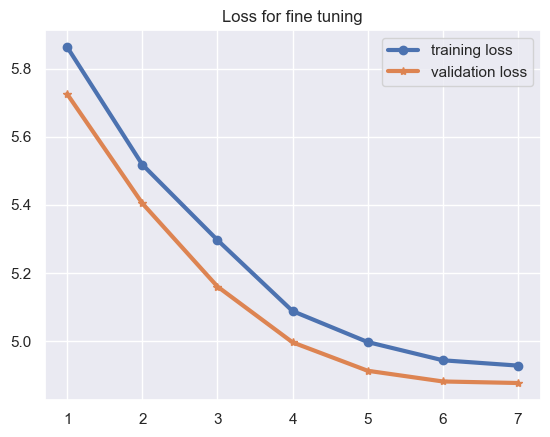

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
epoch = list(range(1,8))
t_loss = [5.863200,5.518100,5.296400,5.087700,4.996700,4.943200,4.927600]
v_loss = [5.725355,5.404383,5.159884,4.995867,4.912416,4.880995,4.876490]
plt.plot(epoch,t_loss,label='training loss',linewidth=3,marker='o')
plt.plot(epoch,v_loss,label='validation loss',linewidth=3,marker='*')
plt.title('Loss for fine tuning')
plt.legend()
plt.show()

`TrainOutput(global_step=1750, training_loss=5.256832685198103, metrics={'train_runtime': 2000.4622, 'train_samples_per_second': 13.997, 'train_steps_per_second': 0.875, 'total_flos': 9487226241024000.0, 'train_loss': 5.256832685198103, 'epoch': 7.0})`

### 模型评估

利用`Tang_testing_data.json`数据集里面的数据对模型进行测试，利用在线版qwen3-max大模型实现对生成效果的对比评估。具体实现过程如下：

- 加载检查点用于推理
- 加载测试数据
- 在没有微调的模型和已经微调的模型中产生并保存结果
- 利用qwen3 max模型对产生的记过进行评估

加载原始基础模型，再加载检查点里的 PEFT 适配器，构建微调后的模型。

In [24]:
base_model = AutoModelForCausalLM.from_pretrained(model_name,dtype="auto",device_map="auto")
model = AutoModelForCausalLM.from_pretrained(model_name,dtype="auto",device_map="auto")
checkpoint_path = 'model/fine_tuning/checkpoint-1750'
model = PeftModel.from_pretrained(model,checkpoint_path)
tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)

In [25]:
generate_tang_poem(model,tokenizer,'秦川雄帝宅，函谷壮皇居。')

'松影随云起，溪声入梦初。松风入蜀道，溪月照玄庐。云外星如箭，星中月似珠。愿将心一寸，寄与幽人躯。'

In [26]:
generate_tang_poem(base_model,tokenizer,'秦川雄帝宅，函谷壮皇居。')

'黄鹤长空去，江云隐旧庐。松声入竹影，雁字过江湖。我欲登高望，心随云外游。'

加载测试数据

In [27]:
file_path = os.path.join(FOLDER_PATH,f'dataset{os.sep}poem{os.sep}Tang_testing_data.json')
testing_data = load_data(file_path)
test_list = [data['input'] for data in testing_data]
print(test_list)

['雪霽銀妝素，桔高映瓊枝。', '夫子何爲者？栖栖一代中。', '飛蓋去芳園，蘭橈遊翠渚。', '條風開獻節，灰律動初陽。', '昨夜星辰昨夜風，畫樓西畔桂堂東。', '三日入廚下，洗手作羹湯。', '嵩雲秦樹久離居，雙鯉迢迢一紙書。', '慨然撫長劒，濟世豈邀名。', '乘興南遊不戒嚴，九重誰省諫書函。', '猿鳥猶疑畏簡書，風雲常爲護儲胥。', '君問歸期未有期，巴山夜雨漲秋池。', '相見時難別亦難，東風無力百花殘。', '雲母屏風燭影深，長河漸落曉星沈。', '高閣客竟去，小園花亂飛。', '瑤池阿母綺窗開，黃竹歌聲動地哀。']


In [28]:
len(test_list)

15

在没有微调和已经微调的模型产生并保存结果

In [43]:
def generate_tangshi_prompts(test_list):
    res_prompts = []
    with tqdm(test_list,ncols=100,colour='green',leave=True) as pbar:
        for t in pbar:
            
            a = generate_tang_poem(base_model,tokenizer,t)
            b =generate_tang_poem(model,tokenizer,t)# generate_tang_poem(finetuned_model,tokenizer,t)
            prompt_a = f'{t}这句诗的续写为后面中括号里面的内容：[{b}]。请分别从情感，诗词结构入手按照10分制给出整体分数，只需要对续写给出最终分数。'
            prompt_b = f'{t}这句诗的续写为后面中括号里面的内容：[{a}]。请分别从情感，诗词结构入手按照10分制给出整体分数，只需要对续写给出最终分数。'
            res_prompts.extend([prompt_a,prompt_b])
    return res_prompts

使用**qwen3-max**为续写打分

In [44]:
res_prompts = generate_tangshi_prompts(test_list)
res_prompts

100%|███████████████████████████████████████████████████████████████| 15/15 [05:56<00:00, 23.80s/it]


['雪霽銀妝素，桔高映瓊枝。这句诗的续写为后面中括号里面的内容：[星垂萬壑無言處，月照千山一寸期。]。请分别从情感，诗词结构入手按照10分制给出整体分数，只需要对续写给出最终分数。',
 '雪霽銀妝素，桔高映瓊枝。这句诗的续写为后面中括号里面的内容：[霜侵玉骨魂，月照冰心思。欲問詩人意，清歌一曲時。]。请分别从情感，诗词结构入手按照10分制给出整体分数，只需要对续写给出最终分数。',
 '夫子何爲者？栖栖一代中。这句诗的续写为后面中括号里面的内容：[山川一隅思，心向故园中。松风入幽巷，竹露润明楼。昔闻诗酒侣，今作客吟俦。但願身外去，心随山海流。]。请分别从情感，诗词结构入手按照10分制给出整体分数，只需要对续写给出最终分数。',
 '夫子何爲者？栖栖一代中。这句诗的续写为后面中括号里面的内容：[山高水长思無限，一朝白首情难分。心随雲水共漂泊，身似浮云随風轉。]。请分别从情感，诗词结构入手按照10分制给出整体分数，只需要对续写给出最终分数。',
 '飛蓋去芳園，蘭橈遊翠渚。这句诗的续写为后面中括号里面的内容：[秋風起，雲起，一叶舟，一舟归。花影斜，月光低，孤舟行，夜静多。]。请分别从情感，诗词结构入手按照10分制给出整体分数，只需要对续写给出最终分数。',
 '飛蓋去芳園，蘭橈遊翠渚。这句诗的续写为后面中括号里面的内容：[孤舟横碧落，一叶落寒霜。（注：续写部分延续了原诗的意境，描绘了诗人独自远行的孤寂与自然景色的清幽，语言凝练，意境深远。）]。请分别从情感，诗词结构入手按照10分制给出整体分数，只需要对续写给出最终分数。',
 '條風開獻節，灰律動初陽。这句诗的续写为后面中括号里面的内容：[**風動柳生新，雲開燕語長。****星垂江岸靜，夢入玉樓香。**若需续写整首诗，可依原意稍作扩展，如：**風動柳生新，雲開燕語長。****星垂江岸靜，夢入玉樓香。****人倚危樓望，雲開雁影斜。****今朝花醉酒，明日月明光。**如需续写整首诗，请提供具体要求。]。请分别从情感，诗词结构入手按照10分制给出整体分数，只需要对续写给出最终分数。',
 '條風開獻節，灰律動初陽。这句诗的续写为后面中括号里面的内容：[**其餘詩句：****其餘詩句：****其餘詩句：****其餘詩句：**]。请分别从情感，诗词结构入手按照10分制给出整体分数，只需要对续写给出最终分数。',
 '昨夜星辰

In [45]:
def model_scoring(prompts,model='qwen3-max',api_key='AL_LLM_API_KEY',base_url='https://dashscope.aliyuncs.com/compatible-mode/v1'):
    # user_secrets = UserSecretsClient()
    # API_KEY =user_secrets.get_secret(api_key)
    API_KEY = os.getenv(api_key)
    client = OpenAI(
                # 若没有配置环境变量，请用阿里云百炼API Key将下行替换为：api_key='sk-xxx',
                api_key=API_KEY,
                base_url=base_url,
            )
    
    scores = []
    contents = []
    for prompt in prompts:
        completion = client.chat.completions.create(
            
            model=model,
            messages=[{'role':'system','content':'你是一位著名的唐诗鉴赏专家,你会直接给出分数值,如果未提供能容，直接打零分。'},{'role': 'user', 'content': prompt}]
        )
        content = completion.choices[0].message.content
        score = re.findall(r'\d+\.?\d*',content) 
        if len(score)==0:
            score = [0]
        elif len(score)>1:
            score = [min(score)]
        contents.append(content)
        scores.extend(score)
    return contents,scores

In [46]:
contents,scores = model_scoring(res_prompts)

In [47]:
def get_score_df(scores):
    scores = [float(s) for s in scores]
    base_score = scores[1::2]
    fine_score = scores[::2]
    score_df = pd.DataFrame({'base model':base_score,'fine tune':fine_score})
    score_df['act greater'] = compare(score_df)
    mean_df = pd.DataFrame(score_df.mean()).T
    max_df = pd.DataFrame(score_df.max()).T
    min_df = pd.DataFrame(score_df.min()).T
    std_df = pd.DataFrame(score_df.std()).T
    score_df = pd.concat([score_df,mean_df,max_df,min_df,std_df],ignore_index=True)
    idxs = list(score_df.index)
    idxs[-4:] = ['mean','max','min','std']
    score_df.set_index(pd.Index(idxs),inplace=True)
    return score_df

def compare(score_df):
    res = []
    for idx,v in enumerate(score_df['fine tune'].values):
        if v > score_df['base model'][idx]:
            res.append(1)
        elif v == score_df['base model'][idx]:
            res.append(0.5)
        else:
            res.append(0)
    return res

In [48]:
score_df = get_score_df(scores)
score_df

,base model,fine tune,act greater
0,8.500000,8.500000,0.500000
1,6.500000,6.500000,0.500000
2,7.500000,6.500000,0.000000
3,0.000000,7.500000,1.000000
4,6.000000,6.500000,1.000000
5,6.500000,6.500000,0.500000
6,6.500000,6.500000,0.500000
7,6.500000,6.500000,0.500000
8,6.500000,6.500000,0.500000
9,6.500000,6.500000,0.500000


通过**智普**大模型为生成的诗句评分

In [35]:
# zp_contents,zp_scores = model_scoring(res_prompts,model='glm-4.5-flash',api_key='ZP_LLM_API_KEY',base_url='https://open.bigmodel.cn/api/paas/v4/')
# get_score_df(zp_scores)

**这部分内容主要用来出来网盘上读取的唐诗300的txt文件**

In [36]:
txt_path = os.path.join(dataset_path,'tangshi300_testing.txt')
with open(txt_path,'r',encoding='utf-8') as f:
    lines = f.readlines()

def clean_txt_poem(lines):
    poems = []
    poem = []
    is_title  = False
    for line in lines:
        numeric_alpha = re.findall(r'\d+?',line) 
        if len(numeric_alpha):
            is_title = True
        elif is_title and not line.strip():
            continue
        elif line.strip():
            poem.append(line)
            is_title = False
        else:
            poem_str = ''.join(poem)
            poem_str = poem_str.replace('\n','')
            len_poem_str = len(poem_str)
            if len_poem_str%2 == 0 and len_poem_str<=100 and '（' not in poem_str and '［' not in poem_str:
                poems.append(poem_str)
            poem = []
    return poems

In [37]:
def get_poems_map(poems):
    poems_map = {'input':[],'output':[]}
    for poem in poems:
        poem_list = poem.split('。').copy()
        poems_map['input'].append(poem_list[0]+'。')
        poems_map['output'].append('。'.join(poem_list[1:]))
    return poems_map

In [38]:
def verification(poems,poems_map):
    for idx,poem in enumerate(poems):
        if len(poem) != len(poems_map['input'][idx]) + len(poems_map['output'][idx]):
            print('error!')
            return False
    else:
        print('finish')
        return True

In [39]:
def save_json_pomes(dataset_path,poems_map):
    res_json_path = os.path.join(dataset_path,'tangshi300_testing.json')
    with open(res_json_path,'w') as f:
        json.dump(poems_map,f)

In [40]:
poems = clean_txt_poem(lines)
poems_map = get_poems_map(poems)
if verification(poems,poems_map):
    save_json_pomes(dataset_path,poems_map)

finish


**这部分主要是简单统计qwen3 max对模型生成结果的评分**

In [52]:
import pandas as pd

最后面后面四行为描述性统计数据，这里并不需要

In [63]:
score_folder_path = os.path.join(FOLDER_PATH,os.path.join('dataset','tang_fine_tuning_score'))
files = ['scoring.csv','scoring (1).csv','scoring (2).csv']
df = pd.concat([pd.read_csv(os.path.join(score_folder_path,file)).iloc[:-4,:] for file in files],ignore_index=True)
df.head() 

,base model,fine tune,act greater,label
0,6.5,8.5,1.0,8.5
1,4.0,6.5,1.0,9.5
2,7.5,6.5,0.0,8.5
3,6.5,6.5,0.5,8.5
4,6.5,6.5,0.5,9.5


In [64]:
df.shape

(798, 4)

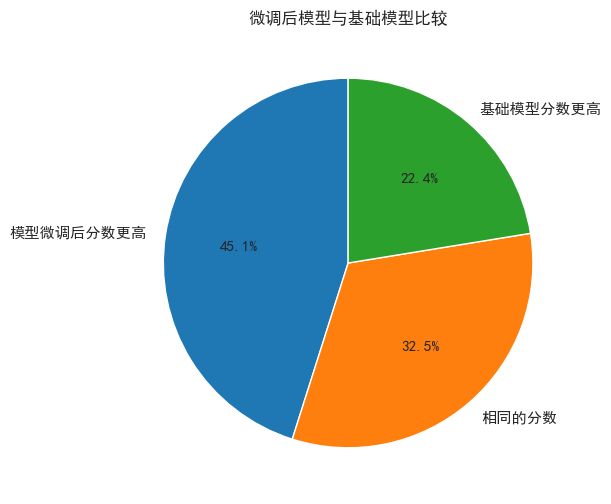

In [72]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

df['act greater'].value_counts().plot(
    kind='pie',
    title='微调后模型与基础模型比较',  
    autopct='%1.1f%%',  
    colors=['#1f77b4', '#ff7f0e', '#2ca02c'],  
    startangle=90,
    labels=['模型微调后分数更高', '相同的分数', '基础模型分数更高'], 
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}, 
    figsize=(8, 6), 
    fontsize=11,
     ylabel=''
)
plt.show()

In [73]:
df.describe()

,base model,fine tune,act greater,label
count,798.000000,798.000000,798.000000,798.000000
mean,5.341103,5.962155,0.613409,8.909524
std,2.046153,1.802472,0.395214,1.091767
min,0.000000,0.000000,0.000000,0.000000
25%,4.000000,6.000000,0.500000,8.500000
50%,6.500000,6.500000,0.500000,9.350000
75%,6.500000,6.500000,1.000000,9.500000
max,9.800000,9.800000,1.000000,9.800000


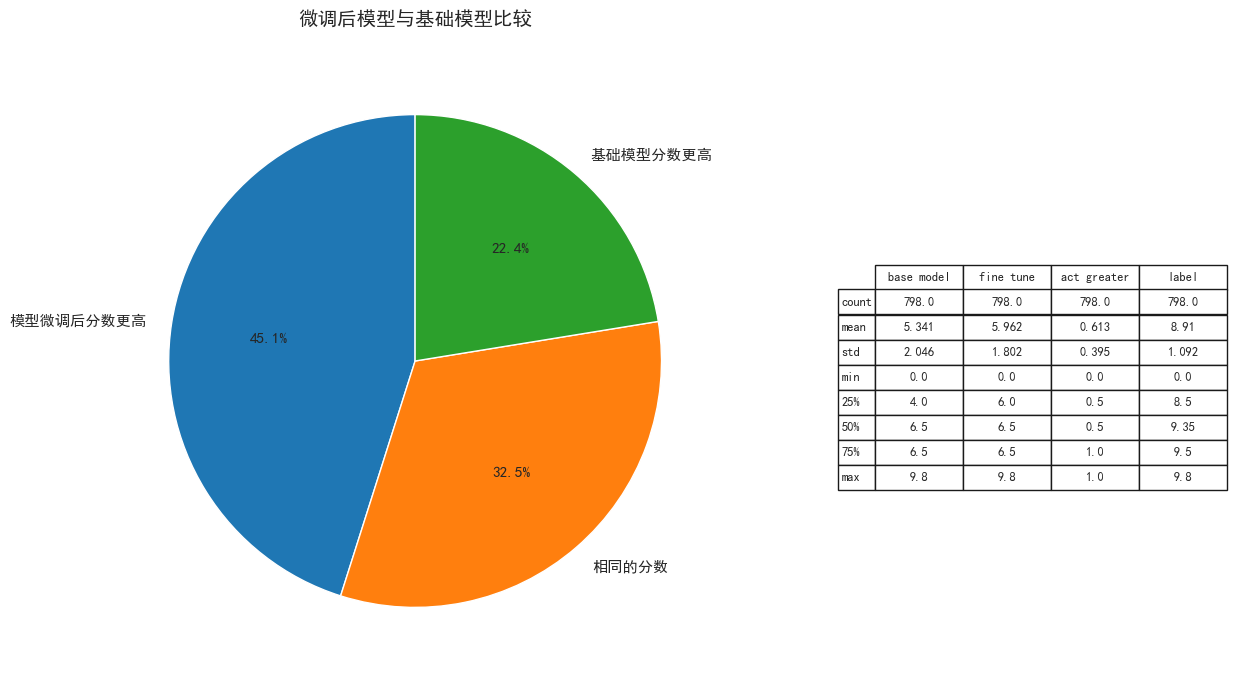

In [75]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 字体配置
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 放大画布（给饼图和表格留足空间）
fig, main_ax = plt.subplots(figsize=(16, 8))  # 加宽加高画布

# 3. 绘制饼图（优化细节）
pie_plot = df['act greater'].value_counts().plot(
    kind='pie',
    ax=main_ax,
    title='微调后模型与基础模型比较',
    autopct='%1.1f%%',
    # 调整百分比文字大小
    textprops={'fontsize': 10},
    colors=['#1f77b4', '#ff7f0e', '#2ca02c'],
    startangle=90,
    labels=['模型微调后分数更高', '相同的分数', '基础模型分数更高'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
    fontsize=11,
    ylabel=''
)
# 增加标题与饼图的间距
main_ax.set_title('微调后模型与基础模型比较', pad=20, fontsize=14)

# 4. 调整表格的位置+大小（更靠右、宽度缩小）
# 坐标格式：[左边界, 下边界, 宽度, 高度]（归一化坐标，范围0-1）
table_ax = fig.add_axes([0.8, 0.1, 0.22, 0.75])  # 右移+加宽高度+缩小宽度
table_ax.axis('off')  # 隐藏表格坐标轴

# 5. 简化表格数据（减少小数位，避免列过宽）
desc_data = df.describe().round(3)  # 保留3位小数

# 6. 绘制表格（优化字体+行高）
table = table_ax.table(
    cellText=desc_data.values,
    colLabels=desc_data.columns,
    rowLabels=desc_data.index,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)  # 缩小表格字体
table.scale(1, 1.5)  # 适度调整行高（避免行太宽）

# 显示图表
plt.show()

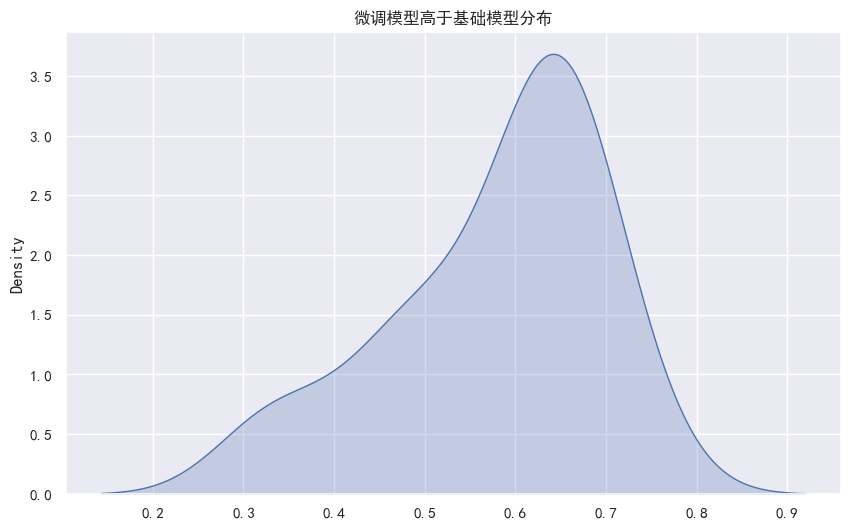

In [81]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.kdeplot([0.73,0.467,0.6,0.667,0.333,0.633,0.633,0.667,0.633,0.60,0.533,0.633,0.667,0.433,0.633,0.7,0.5,0.667,0.5,0.333],fill=True)
plt.title('微调模型高于基础模型分布')
plt.show()